In [2]:
from reedsolo import RSCodec
import os
import matplotlib.pyplot as plt

import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from rs.channels import qsc_erasure_channel

In [3]:
def measure_baseline(p_err, p_erase, num_samples=2000):
    rsc = RSCodec(32)

    classic_no_hint = 0
    classic_with_hint = 0

    total_errors = 0
    total_erasures = 0

    for _ in range(num_samples):
        msg = os.urandom(223)
        codeword = rsc.encode(msg)
        noisy, erasure_positions = qsc_erasure_channel(codeword, p_err, p_erase)

        error_count = sum(1 for i, (a, b) in enumerate(zip(codeword, noisy))
                          if a != b and i not in erasure_positions)
        total_errors += error_count
        total_erasures += len(erasure_positions)

        try:
            decoded, _, _ = rsc.decode(noisy)
            if bytes(decoded) == msg:
                classic_no_hint += 1
        except:
            pass

        try:
            decoded, _, _ = rsc.decode(noisy, erase_pos=erasure_positions)
            if bytes(decoded) == msg:
                classic_with_hint += 1
        except:
            pass
    
    return {
        'no_hint': classic_no_hint / num_samples,
        'with_hint': classic_with_hint / num_samples,
        'gap': (classic_with_hint - classic_no_hint) / num_samples,
        'avg_errors': total_errors / num_samples,
        'avg_erasures': total_erasures / num_samples,
    }

In [11]:
def run_baseline_experiments():

    p_err = 0.02
    p_erase_values = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14]

    results = []

    print(f"{'p_err':<8} {'p_erase':<8} {'Errors':<8} {'Erasures':<10} {'No hint':<10} {'With hint':<10} {'Gap':<10}")
    print("-" * 70)

    for p_erase in p_erase_values:
        r = measure_baseline(p_err, p_erase, num_samples=2000)
        r['p_err'] = p_err
        r['p_erase'] = p_erase
        results.append(r)

        print(f"{p_err:<8} {p_erase:<8} {r['avg_errors']:<8.1f} {r['avg_erasures']:<10.1f} "
              f"{r['no_hint']:<10.3f} {r['with_hint']:<10.3f} {r['gap']:<10.3f}")

    return results

In [5]:
def plot_baseline(results):
    p_erase = [r['p_erase'] for r in results]
    no_hint = [r['no_hint'] for r in results]
    with_hint = [r['with_hint'] for r in results]

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(p_erase, with_hint, 'g-o', linewidth=2, markersize=8, label='Classic + hint (upper bound)')
    ax.plot(p_erase, no_hint, 'r-s', linewidth=2, markersize=8, label='Classic (no hint)')

    ax.fill_between(p_erase, no_hint, with_hint, alpha=0.3, color='blue', label='Gap (potential for improvement)')
    
    ax.set_xlabel('Erasure probability (p_erase)', fontsize=12)
    ax.set_ylabel('Frame Success Rate (FSR)', fontsize=12)
    ax.set_title(f'RS(255, 223) Decoder Performance\np_err = 0.02', fontsize=14)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(min(p_erase), max(p_erase))
    ax.set_ylim(0, 1.05)

    mid_idx = len(p_erase) // 2
    mid_x = p_erase[mid_idx]
    mid_y = (no_hint[mid_idx] + with_hint[mid_idx]) / 2
    ax.annotate('Neural network\ncan fill this gap!',
                xy=(mid_x, mid_y),
                xytext=(mid_x + 0.03, mid_y),
                fontsize=11,
                ha='left',
                arrowprops=dict(arrowstyle='->', color='blue'))

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_theoretical_limit(results):

    fig, ax = plt.subplots(figsize=(10, 6))

    p_erase = [r['p_erase'] for r in results]
    avg_errors = [r['avg_errors'] for r in results]
    avg_erasures = [r['avg_erasures'] for r in results]

    total_damage = [e + s for e, s in zip(avg_errors, avg_erasures)]
    cost_no_hint = [2 * t for t in total_damage]
    cost_with_hint = [2 * e + s for e, s in zip(avg_errors, avg_erasures)]
    
    ax.axhline(y=32, color='black', linestyle='--', linewidth=2, label='Limit (2t = 32)')
    ax.plot(p_erase, cost_no_hint, 'r-s', linewidth=2, markersize=8, label='Cost: 2×(errors + erasures)')
    ax.plot(p_erase, cost_with_hint, 'g-o', linewidth=2, markersize=8, label='Cost: 2×errors + erasures')
    ax.fill_between(p_erase, cost_with_hint, [32]*len(p_erase), 
                     where=[c <= 32 for c in cost_with_hint], alpha=0.3, color='green', label='Can correct (with hint)')
    ax.set_xlabel('Erasure probability', fontsize=12)
    ax.set_ylabel('Correction cost', fontsize=12)
    ax.set_title('Why hint helps: Erasures are cheaper', fontsize=14)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

p_err    p_erase  Errors   Erasures   No hint    With hint  Gap       
----------------------------------------------------------------------
0.02     0.02     5.1      5.0        0.977      1.000      0.022     
0.02     0.04     5.1      10.2       0.642      0.984      0.342     
0.02     0.06     5.0      15.2       0.211      0.891      0.680     
0.02     0.08     5.1      20.4       0.035      0.650      0.616     
0.02     0.1      5.0      25.6       0.004      0.325      0.321     
0.02     0.12     5.1      30.5       0.000      0.110      0.110     
0.02     0.14     5.0      35.8       0.000      0.025      0.025     


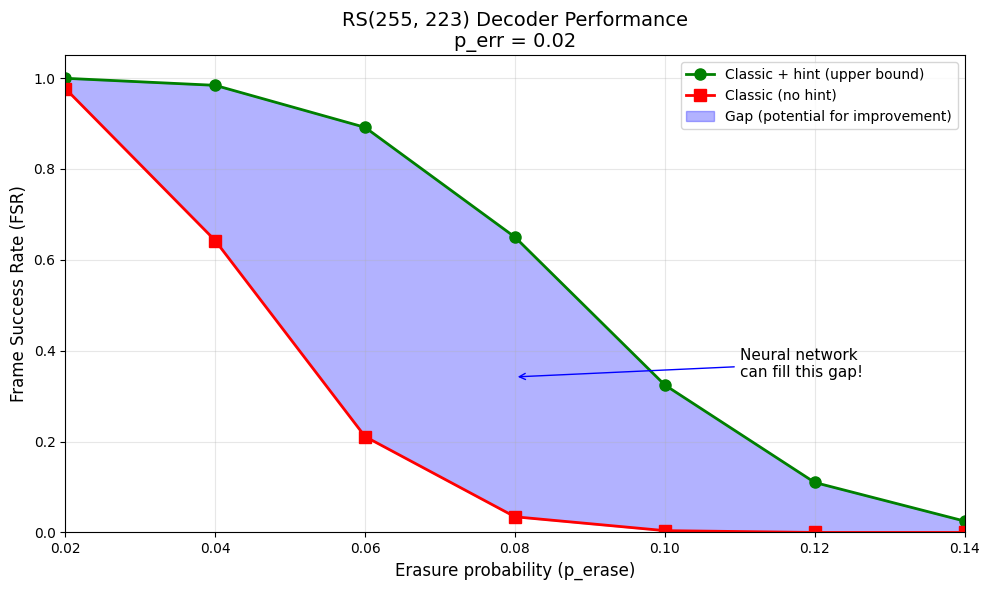

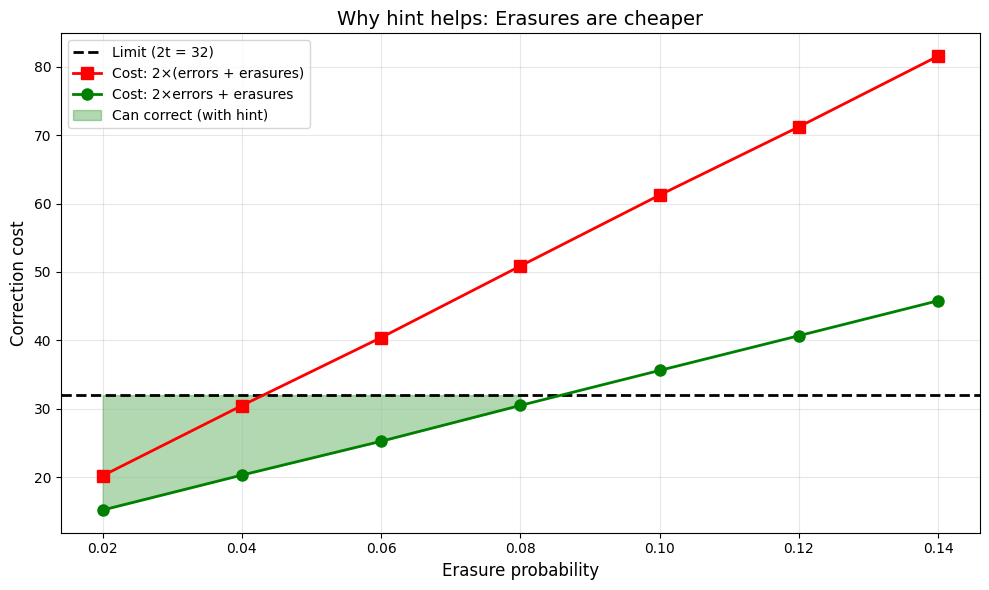

In [12]:
if __name__ == "__main__":
    results = run_baseline_experiments()

    plot_baseline(results)
    plot_theoretical_limit(results)